# ML04: Decision Trees

## Introduction

A Decision Tree is a tree-like model used for classification and regression tasks. It splits data into branches based on feature conditions until it reaches a decision.

The training process involves constructing the tree from a given dataset, starting at the root node and selecting a feature at each step to split the data.

## How to select the best feature?

When constructing a decision tree, the goal is to choose the feature that best splits the data into pure subsets. **Information Gain (IG)** is the metric used to measure how much a given split improves the purity of the resulting child nodes. For a dataset $X$ that takes on values in set $\mathcal{V}$ and a feature $a$, IG is defined as the decrease in a criterion after splitting:
|
$$
\boxed{IG(X, a) = f(X) - \sum_{v \in \mathcal{V}} \frac{|X_v|}{|X|} f(X_v)}
$$

where:

- $f(\cdot)$ is a criterion that measures the "randomness".
- $X_v$ is the subset of $X$ with the feature $a$ taking on value $v$.
- $|X|$ is the number of examples in $X$.

In simple terms, IG is equal to the criterion measured before the split minus the weighted average of the criterion measured after the split. A large positive value of IG indicates that the feature is a good candidate for splitting.

Two common criteria used for $f$ are **Shannon entropy** and **Gini impurity**.

### Shannon Entropy

Shannon entropy measures the disorder in a dataset. It is defined as:

$$
\boxed{H(X) = - \sum_{i} p_i \log_{2} p_i}
$$

where $p_i$ is the proportion of items belonging to class $i$ in the dataset. The lower the entropy, the higher the purity of the dataset.

A calculation example:

In [1]:
import numpy as np

In [2]:
def shannon_entropy(X):
    _, counts = np.unique(X, return_counts=True)
    prob = counts / np.sum(counts)
    return -np.sum(prob * np.log2(prob))

In [3]:
arr1 = np.array([2, 2, 1, 2, 2, 2, 3, 1, 1, 2])
arr2 = np.array([1, 3, 2, 4, 5, 8, 9, 1, 2, 7])
shannon_entropy(arr1), shannon_entropy(arr2)

(1.295461844238322, 2.9219280948873623)

> **Side Note:**
> 
> The entropy of $X$ ($X$ is treated as a random variable here) is defined as the expected value of the self-information of its outcomes, i.e.,  
> $$H(X) = E[I(X)] = \sum_{x} p(x) I(x)$$
> 
> Here, the self-information (or "surprisal") of an outcome $x$ is defined as:
> $$I(x) = -\log_2 p(x)$$
> 
> This definition has several desirable properties:  
> - Lower probability events are more surprising: When an event is rare (low $p(x)$), it carries more information upon occurrence.  
> - Additivity for independent events: The logarithm function converts multiplication into addition, ensuring that the total information for independent events is the sum of their individual informations.


### Gini Impurity

Gini impurity measures the likelihood that a randomly chosen element from a dataset would be misclassified if it were labeled according to the distribution of labels in that dataset. It is given by:

$$
\boxed{\text{Gini}(X) = \sum_{i\ne j} p_ip_j = 1 - \sum_{i} p_i^2}
$$

where $p_i$ is the proportion of items belonging to class $i$ in the dataset. This formula can be interpreted as the probability that two randomly drawn items from the dataset (where one is treated as the sample and the other as the label) belong to different classes. This [answer on StackExchange](https://stats.stackexchange.com/a/339514) provides a clear explanation, which you may find helpful.

In practice, the choice between Shannon entropy and Gini impurity as the splitting criterion makes little difference. However, Gini impurity is more commonly used since it avoids logarithmic calculations and is therefore computationally less expensive.

> **Side Note:**
>
> Given that the taylor expansion of $\ln (1+x)$ is:
>
> $$\ln(1+x) = x - \frac{x^2}{2} + \frac{x^3}{3} - \frac{x^4}{4} + \dots$$
>
> We approximate:
>
> $$\begin{aligned}H(X) &= - \sum_{i} p_i \log_{2} p_i  \\  &= -\frac{1}{\ln2}\sum_{i} p_i \ln p_i  \\  &= -\frac{1}{\ln2}\sum_{i} p_i \left((p_i - 1) - \frac{(p_i - 1)^2}{2} + \frac{(p_i - 1)^3}{3} - \frac{(p_i - 1)^4}{4} + \dots\right)  \\  &\approx 1.44 \sum_{i}p_i(1-p_i)  \\  &\approx 1.44 \left(1 - \sum_{i} p_i^2\right)  \\  &\approx I_G(X)\end{aligned}$$
>
> This explains why the two criteria yield similar results in practice.

## Implementing Decision Trees

In [4]:
import pandas as pd
from typing import Any
from graphviz import Digraph
from uuid import uuid4

In [5]:
df_mushrooms = pd.read_csv("datasets/mushrooms.csv")  # https://www.kaggle.com/datasets/uciml/mushroom-classification?resource=download
X1 = df_mushrooms.drop('class', axis=1)
y1 = df_mushrooms['class']
df_mushrooms

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


> Attribute Information: (classes: edible=e,  poisonous=p)
> - cap-shape: bell=b, conical=c, convex=x, flat=f,  knobbed=k, sunken=s
> - cap-surface: fibrous=f, grooves=g, scaly=y, smooth=s
> - cap-color: brown=n, buff=b, cinnamon=c, gray=g, green=r, pink=p, purple=u, red=e, white=w, yellow=y
> - bruises: bruises=t, no=f
> - odor: almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s
> - gill-attachment: attached=a, descending=d, free=f, notched=n
> - gill-spacing: close=c, crowded=w, distant=d
> - gill-size: broad=b, narrow=n
> - gill-color: black=k, brown=n, buff=b, chocolate=h, gray=g,  green=r, orange=o, pink=p, purple=u, red=e, white=w, yellow=y
> - stalk-shape: enlarging=e, tapering=t
> - stalk-root: bulbous=b, club=c, cup=u, equal=e, rhizomorphs=z, rooted=r, missing=?
> - stalk-surface-above-ring: fibrous=f, scaly=y, silky=k, smooth=s
> - stalk-surface-below-ring: fibrous=f, scaly=y, silky=k, smooth=s
> - stalk-color-above-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
> - stalk-color-below-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y
> - veil-type: partial=p, universal=u
> - veil-color: brown=n, orange=o, white=w, yellow=y
> - ring-number: none=n, one=o, two=t
> - ring-type: cobwebby=c, evanescent=e, flaring=f, large=l, none=n, pendant=p, sheathing=s, zone=z
> - spore-print-color: black=k, brown=n, buff=b, chocolate=h, green=r, orange=o, purple=u, white=w, yellow=y
> - population: abundant=a, clustered=c, numerous=n, scattered=s, several=v, solitary=y
> - habitat: grasses=g, leaves=l, meadows=m, paths=p, urban=u, waste=w, woods=d

In [6]:
class DecisionTree:
    def __init__(self):
        self.tree = {}
        self.n_features = 0
        self.graph = None
        
    def fit(self, X: pd.DataFrame, y: pd.Series):
        def _inner(X, y):
            best_feature, splitted = self.__choose_feature(X, y)
            tree = {"feature": best_feature, "results": splitted}
            for val, xy in splitted.items():
                X_excluded = xy[0].drop(best_feature, axis=1)
                y_of_val = xy[1]
                
                if len(y_of_val.unique()) > 1 and len(X_excluded.columns) > 1:
                    tree["results"][val] = _inner(X_excluded, y_of_val)
                else:
                    tree["results"][val] = y_of_val.mode().iloc[0]
            return tree

        self.graph = None
        self.n_features = len(X.columns)
        self.tree = _inner(X, y)
    
    def __choose_feature(self, X: pd.DataFrame, y: pd.Series) -> str:
        mx_val = -np.inf
        corr_feature_name = ""
        corr_splitted = None
        
        for col_name in X.columns:
            if len(X[col_name].unique()) < 2:
                continue
            val, splitted = self.__information_gain(X, y, col_name)
            if val > mx_val:
                mx_val = val
                corr_feature_name = col_name
                corr_splitted = splitted
        return corr_feature_name, corr_splitted

    @staticmethod
    def shannon_entropy(arr: np.array) -> float:
        _, counts = np.unique(arr, return_counts=True)
        prob = counts / np.sum(counts)
        return -np.sum(prob * np.log2(prob))

    def __information_gain(self, X: pd.DataFrame, y: pd.Series, feature_to_split: str) -> float:
        bef = self.shannon_entropy(y)
        aft = 0

        res = {}
        for unique_val in np.unique(X[feature_to_split]):
            mask = X[feature_to_split] == unique_val
            y_masked = y[mask]
            aft += len(y_masked) / len(y) * self.shannon_entropy(y_masked.to_numpy())
            res[unique_val] = (X[mask], y_masked)
            
        return bef - aft, res

    def __predict_one(self, X: pd.Series) -> Any:
        assert len(X) == self.n_features, f"Incorrect no. of features: expected {self.n_features}, got {len(X)}"

        struct = self.tree
        while type(struct) is dict:
            feature = struct["feature"]
            val = X[feature]
            try:
                struct = struct["results"][val]
            except KeyError:
                raise ValueError(f"feature '{feature}' of value '{val}' is not recognised")
        return struct
        
    def predict(self, X: pd.DataFrame) -> pd.Series:
        return X.apply(self.__predict_one, axis=1)

    def draw_tree(self) -> Digraph:
        if self.graph is not None:
            return self.graph
        
        graph = Digraph(format="png")
        graph.attr("node", shape="box")
        
        def _inner(struct, parent_id=None, edge_label=None):
            node_id = str(uuid4())
            
            if type(struct) is not dict:
                graph.node(node_id, struct, shape="ellipse")
                graph.edge(parent_id, node_id, edge_label)
                return

            node_label = struct["feature"]
            graph.node(node_id, node_label)

            if parent_id is not None:
                graph.edge(parent_id, node_id, label=edge_label)

            struct = struct["results"]
            for k, v in struct.items():
                _inner(struct[k], node_id, k)
            
        _inner(self.tree)
        self.graph = graph
        return graph

In [7]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [8]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, train_size=0.6, random_state=42)

In [9]:
dt = DecisionTree()
dt.fit(X1_train, y1_train)

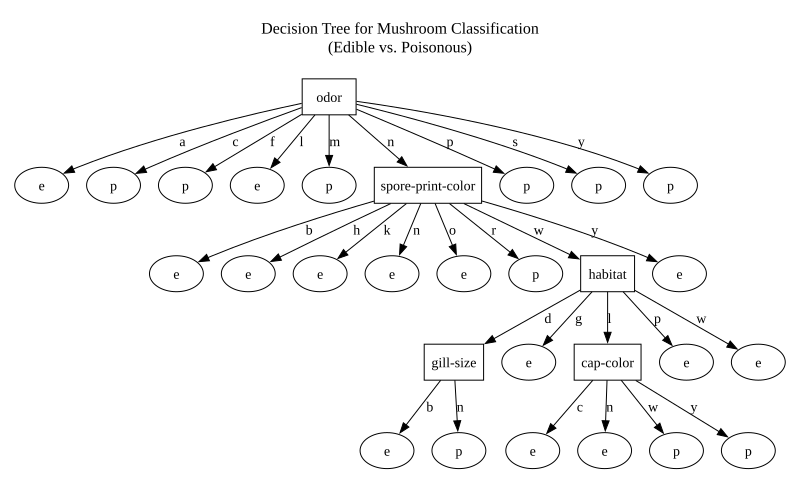

In [10]:
graph = dt.draw_tree()
graph.attr(label="Decision Tree for Mushroom Classification\n(Edible vs. Poisonous)\n\n", labelloc="t", pad="0.2", fontsize="16")
graph

In [11]:
y1_pred = dt.predict(X1_test)
accuracy_score(y1_test, y1_pred)

1.0

Comparing the raw dataframe, the decision tree highlights the most informative attributes that effectively split the data into edible and poisonous classes.

The primary advantage of a decision tree model is its **high interpretability**—it clearly shows which features are critical. Additionally, it does not require preselection; even with many irrelevant or redundant (highly correlated) features, the algorithm automatically evaluates each feature's splitting ability.

However, this strength can also lead to overfitting if the dataset is highly complex or if the tree grows too deep.

### About Continuous Data

Decision trees can handle continuous (numerical) data. The algorithm finds an optimal threshold to split the data into two subsets. Instead of creating multiple branches at once, further splits are performed recursively at the child nodes.

In scikit-learn, data has to be numerical. Categorical features must be preprocessed using techniques such as one-hot encoding or ordinal encoding before training a decision tree. We will now demonstrate this with a hands-on example.

## Using Scikit-Learn

In [12]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OrdinalEncoder

In [13]:
oe = OrdinalEncoder()
X1_train_enc = pd.DataFrame(oe.fit_transform(X1_train), columns=X1_train.columns)
X1_test_enc = pd.DataFrame(oe.transform(X1_test), columns=X1_test.columns)

In [14]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X1_train_enc, y1_train)

DecisionTreeClassifier(random_state=42)

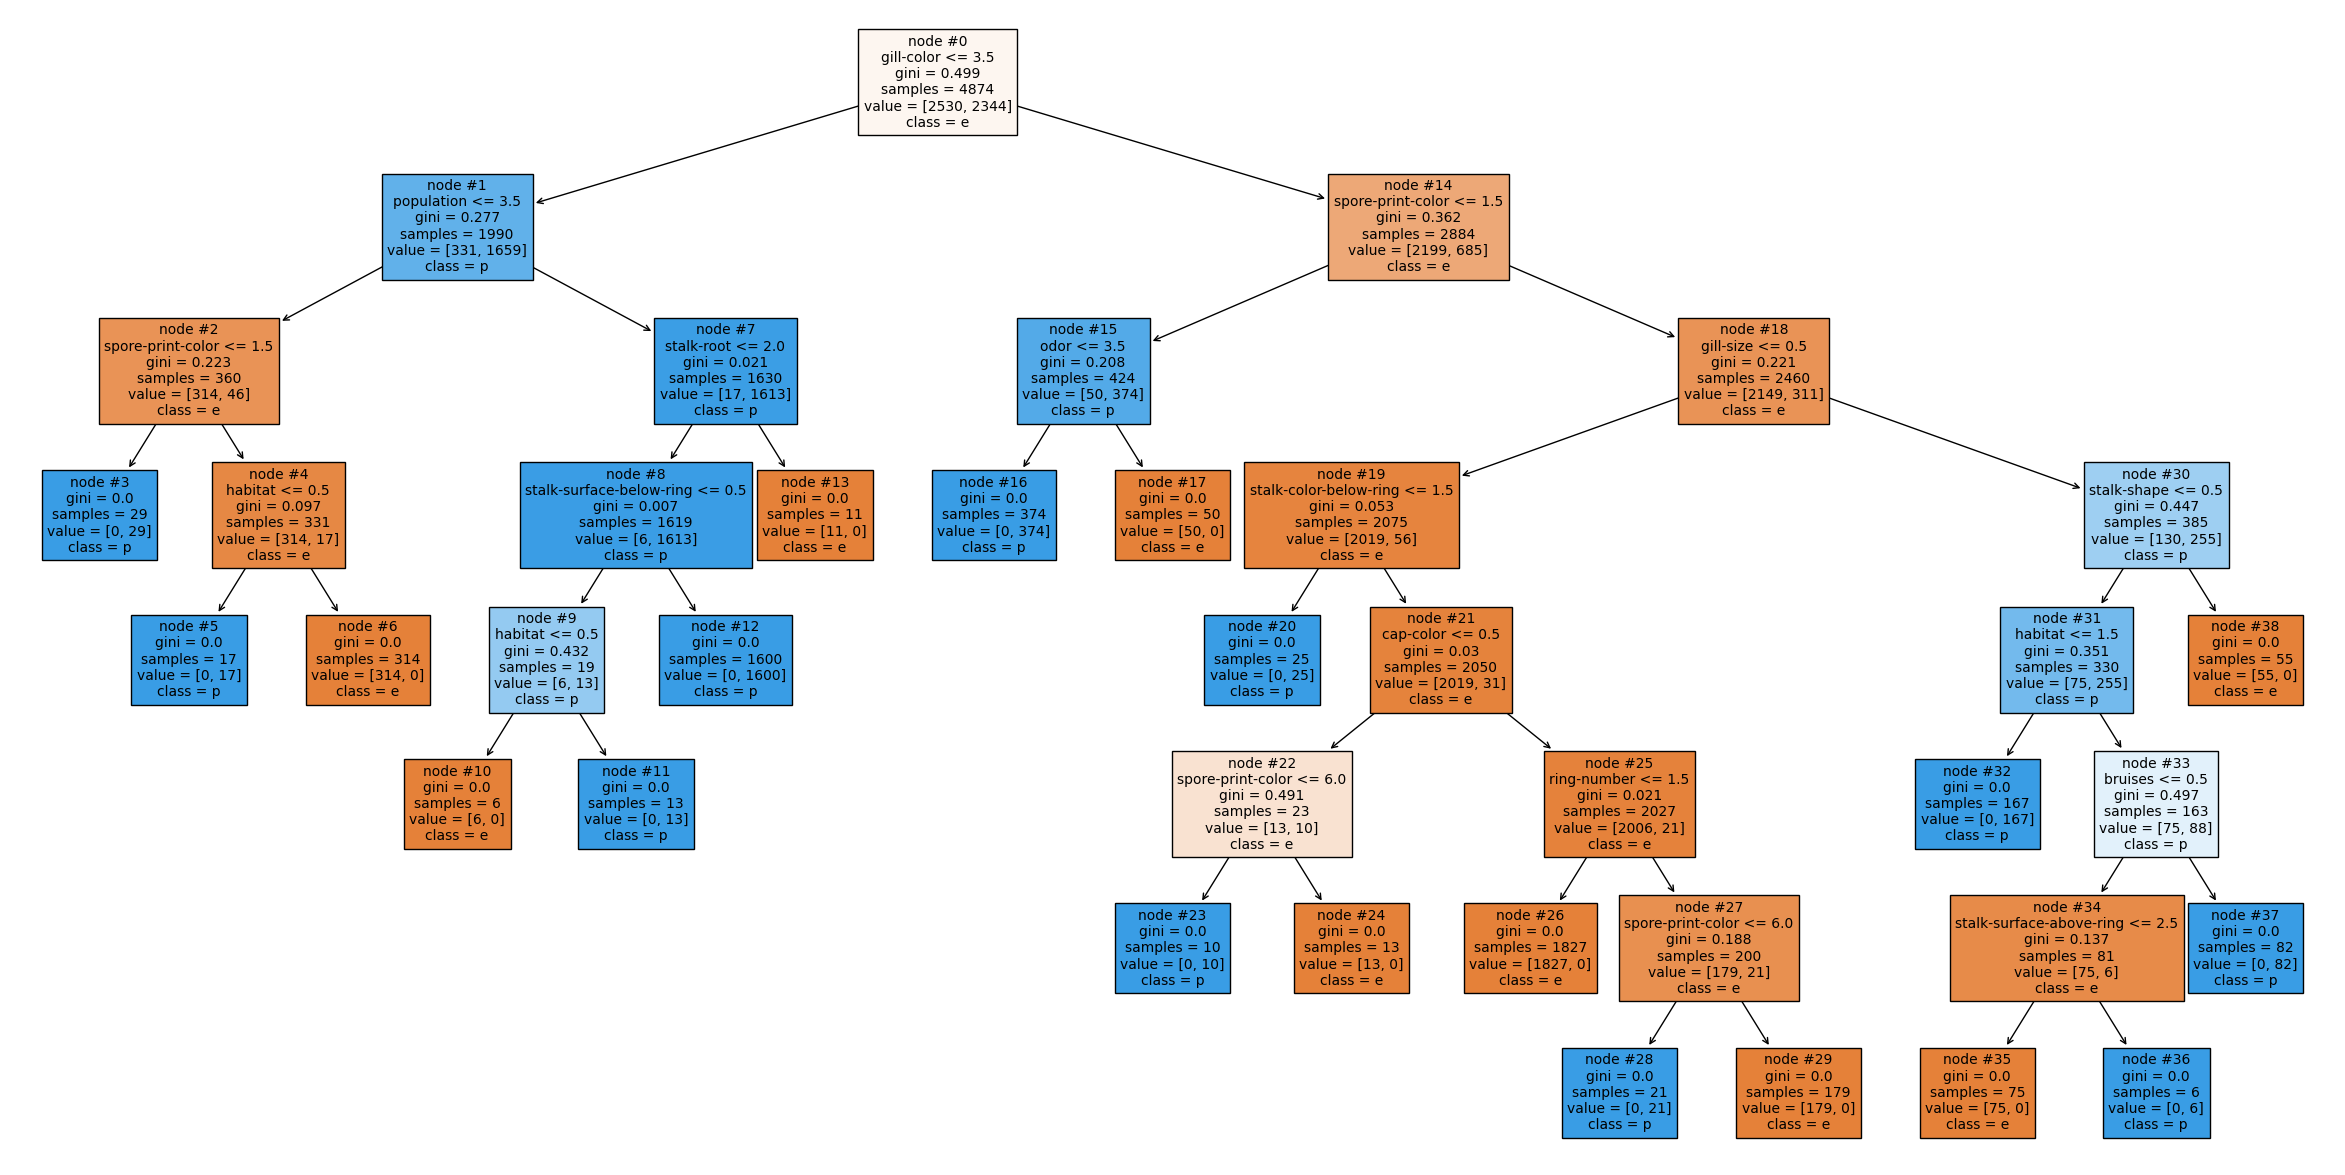

In [15]:
fig, ax = plt.subplots(figsize=(30, 15))  # to adjust size
tree_texts = plot_tree(dtc, ax=ax, fontsize=10, filled=True, node_ids=True,
                       feature_names=X1_train_enc.columns, class_names=dtc.classes_.astype(str));

In [16]:
dtc.score(X1_test_enc, y1_test)  # Mean accuracy

1.0

### About Regression

Not only for classification, decision trees can also be used for regression. In this case, the prediction is made by taking the average of the target values of the samples in each leaf node. 

The corresponding scikit-learn class is called `DecisionTreeRegressor`. It uses MSE as the default criterion to determine the best splits.

### Feature Importance

The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature.

In [17]:
from sklearn.datasets import load_breast_cancer

In [18]:
X2, y2 = load_breast_cancer(return_X_y=True, as_frame=True)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, random_state=42)

In [19]:
dtc1 = DecisionTreeClassifier(random_state=42)
dtc1.fit(X2_train, y2_train)

DecisionTreeClassifier(random_state=42)

In [20]:
dtc1.score(X2_test, y2_test)

0.951048951048951

In [21]:
dtc1.feature_importances_

array([0.        , 0.02601101, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.69593688, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.01277192, 0.00155458,
       0.        , 0.00670697, 0.01702539, 0.        , 0.        ,
       0.0877369 , 0.10787925, 0.        , 0.03452044, 0.00985664,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [22]:
fimportnace, flabel = dtc1.feature_importances_, X2_train.columns
mask = fimportnace > 0.0
fimportance = fimportnace[mask]
flabel = flabel[mask]

sorted_indices = np.argsort(fimportance)[::-1]

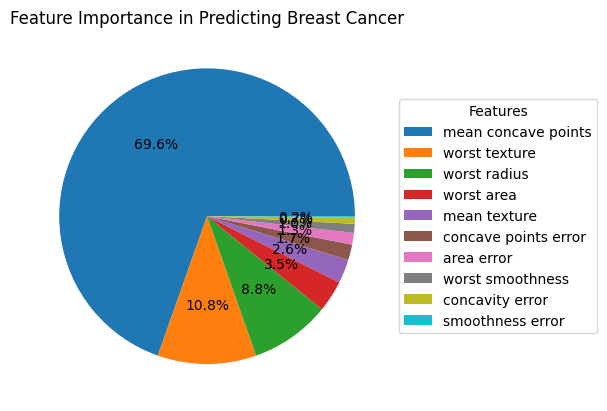

In [23]:
wedges, *_ = plt.pie(fimportance[sorted_indices], autopct='%1.1f%%')
plt.legend(wedges, flabel[sorted_indices], title="Features", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Feature Importance in Predicting Breast Cancer", loc="center");

## Pruning

### Pre-pruning

To prevent overfitting, we can limit the complexity of a decision tree by restricting its growth during training. In scikit-learn, several hyperparameters are used for this purpose:

- `max_depth` limits the maximum depth of the tree.
- `min_samples_split` specifies the minimum number of samples required to split an internal node.
- `min_samples_leaf` determines the minimum number of samples a leaf node must have.
- `max_leaf_nodes` limits the total number of leaf nodes.
- `max_features` limits the number of features to consider when looking for the best split.
- `min_impurity_decrease` specifies the minimum IG* required to split an internal node.

*\*: scikit-learn uses a weighted IG. It is calculated as (the number of samples at the current node) / (total number of samples) * IG.*

The example below demonstrates how adjusting max_depth affects the model's fit on a regression task:

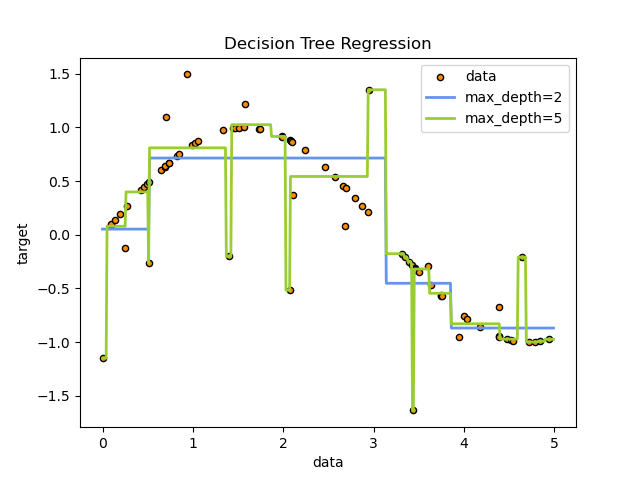 \
*(Image from [sklearn.org](https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html))*

### Post-pruning

Unlike pre-pruning, post-pruning refines an already-grown tree by removing those sections that contribute little to the model’s generalization performance.

One common post-pruning method is **cost-complexity pruning**. For each non-leaf node $t$, we compute an effective cost-complexity parameter:

$$
\boxed{\alpha_t = \frac{R(t) - R(T_t)}{|\stackrel{\sim}{T_t}| - 1}}
$$

where:

- $R(t)$ is the total sample weighted impurity of node $t$.
- $R(T_t)$ is the total sample weighted impurity of the leaf nodes in the subtree with node $t$ as the root.
- $|\stackrel{\sim}{T_t}|$ is the number of leaves in subtree $T_t$.

Basically, $\alpha_t$ measures the average increase in impurity per pruned leaf that would result if the entire subtree rooted at node $t$ were replaced by a single leaf. A lower $\alpha_t$ indicates that turning node $t$ into a leaf (thus pruning its subtree) incurs a small cost in impurity, making it an attractive candidate for pruning.

In the example below, we compute all effective $\alpha$s that will cause a pruning in some branches.

In [24]:
from copy import deepcopy as copy

In [25]:
def compute_effective_alphas(tree):
    tree = copy(tree)
    n_total_samples = tree.n_node_samples[0]

    def _inner():
        mn = np.inf
        mn_idx = None

        def _dfs(node_id):
            l = tree.children_left[node_id]
            r = tree.children_right[node_id]
    
            R_self = tree.impurity[node_id] * tree.n_node_samples[node_id] / n_total_samples
            if l == r == -1:
                return R_self, 1
    
            R_tree = 0
            n_leaves = 0
            for child in (l, r):
                if child != -1:
                    a, b = _dfs(child)
                    R_tree += a
                    n_leaves += b

            nonlocal mn, mn_idx
            eff_alpha = (R_self - R_tree) / (n_leaves - 1)
            if eff_alpha < mn:
                mn = eff_alpha
                mn_idx = node_id
            return R_tree, n_leaves

        _dfs(0)
        return mn, mn_idx

    eff_alphas = [0]
    nodes_pruned = [None]
    while tree.children_left[0] != -1 and tree.children_right[0] != -1:
        mn, mn_idx = _inner()
        eff_alphas.append(mn)
        nodes_pruned.append(mn_idx)
        tree.children_left[mn_idx] = tree.children_right[mn_idx] = -1
    return np.array(eff_alphas), np.array(nodes_pruned)

In [26]:
eff_alphas, pruning_seq = compute_effective_alphas(dtc.tree_)
eff_alphas, pruning_seq

(array([0.        , 0.00122646, 0.00227967, 0.00231932, 0.00340296,
        0.00445012, 0.00661752, 0.00983072, 0.00984626, 0.01075072,
        0.01155082, 0.01809757, 0.05379153, 0.08474121, 0.0898643 ,
        0.17171959]),
 array([None, 8, 34, 22, 21, 7, 4, 19, 2, 31, 30, 15, 18, 14, 1, 0],
       dtype=object))

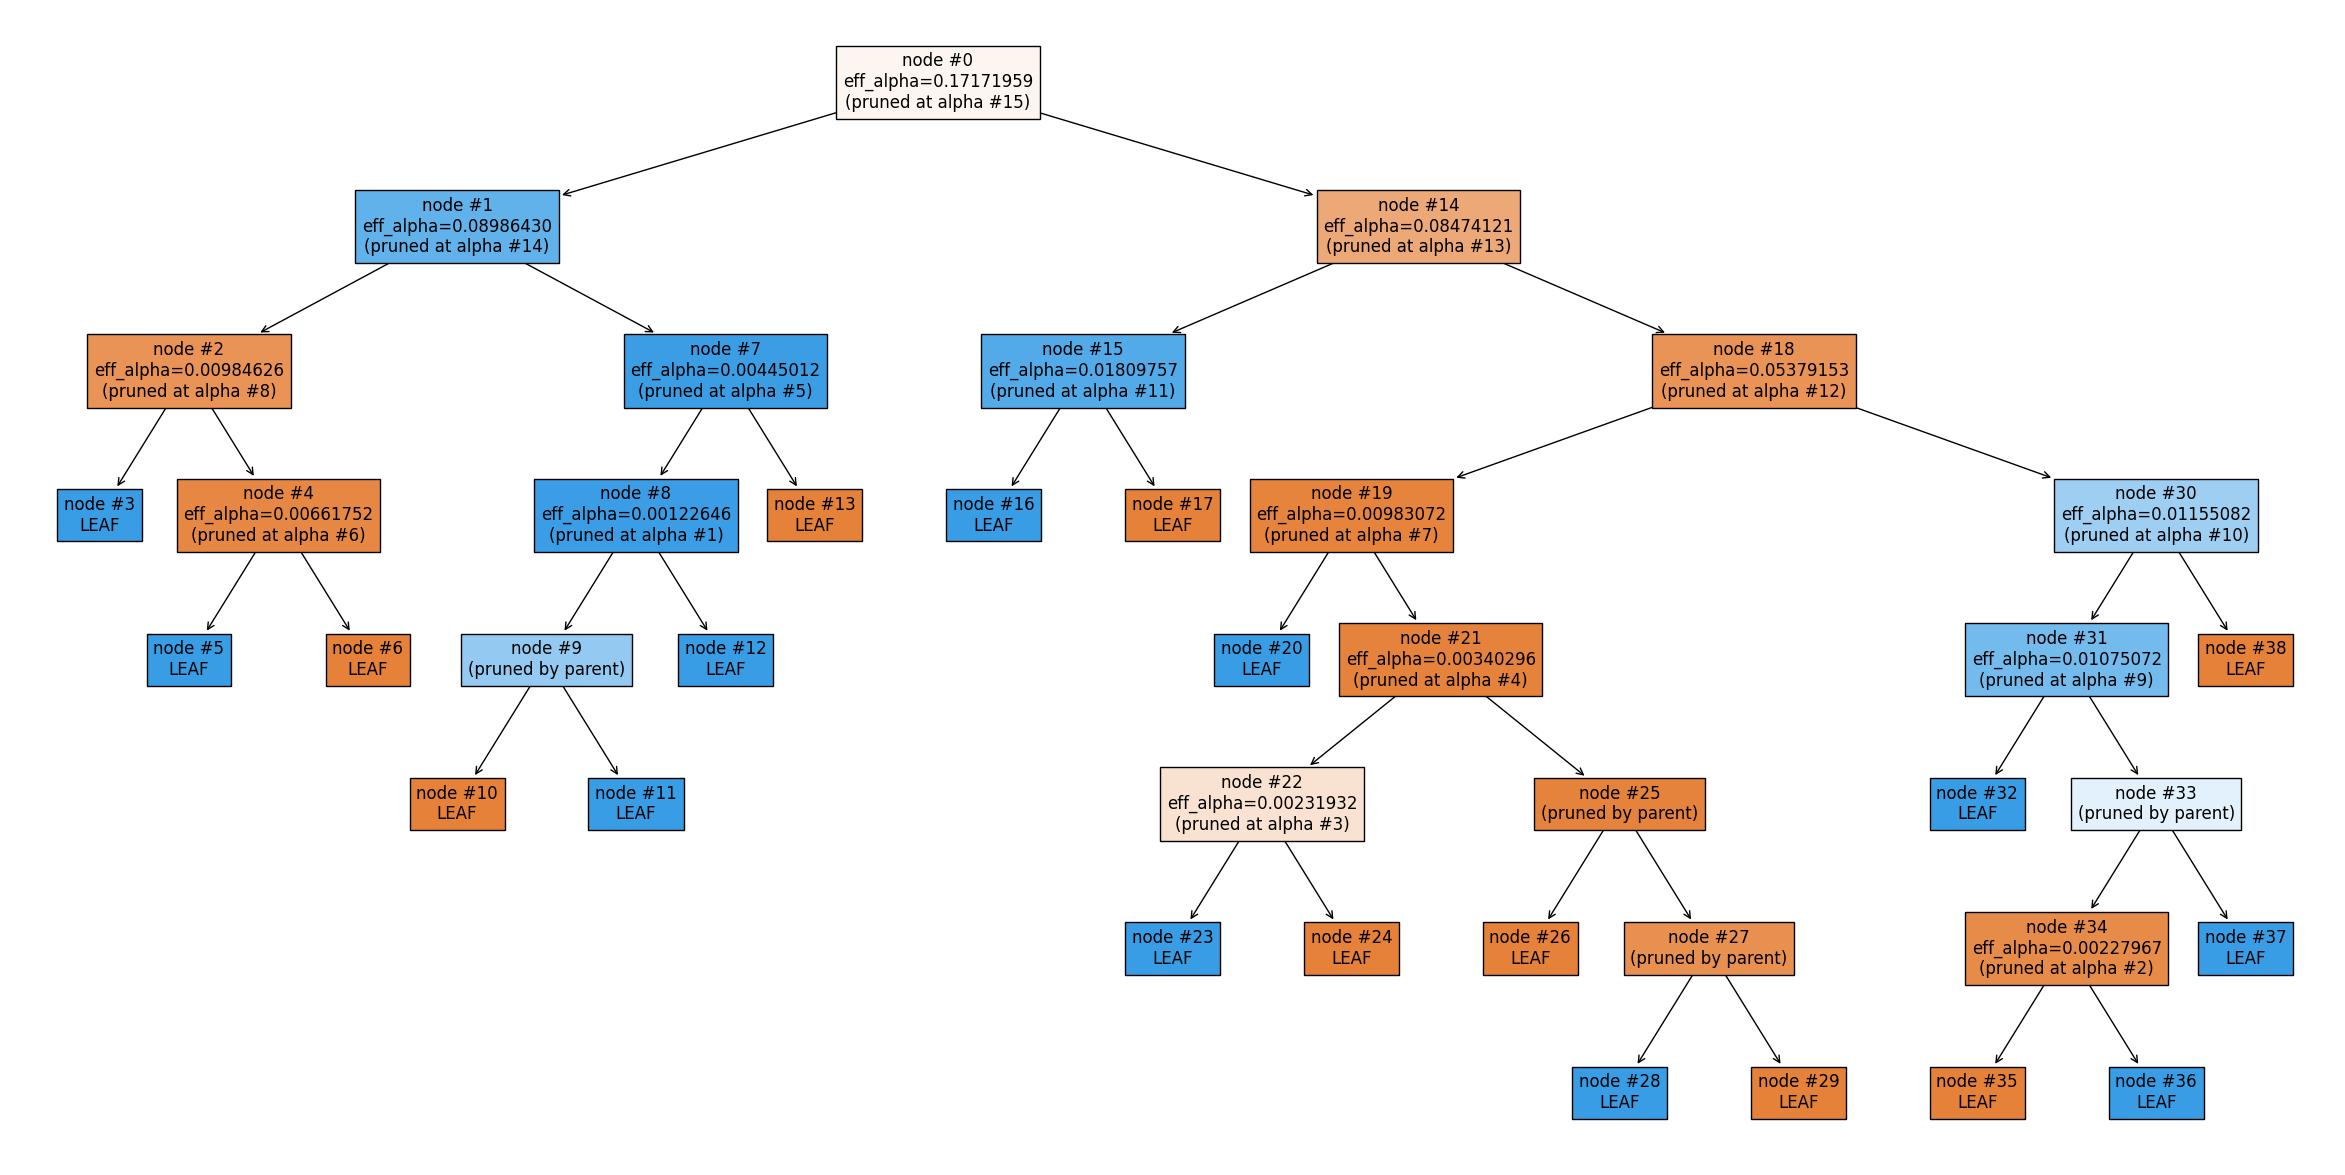

In [27]:
for idx, t in enumerate(tree_texts):
    t.set_fontsize(12)
    t.set_text(f"node #{idx}\n(pruned by parent)")

for no, idx in enumerate(pruning_seq[1:], 1):
    tree_texts[idx].set_text(f"node #{idx}\neff_alpha={eff_alphas[no]:.8f}\n(pruned at alpha #{no})")

for idx in np.where(dtc.tree_.children_left == dtc.tree_.children_right)[0]:
    tree_texts[idx].set_text(f"node #{idx}\nLEAF")

fig

In scikit-learn, we can specify the `ccp_alpha` hyperparameter. All branches with $\alpha$ smaller than this threshold will be pruned.

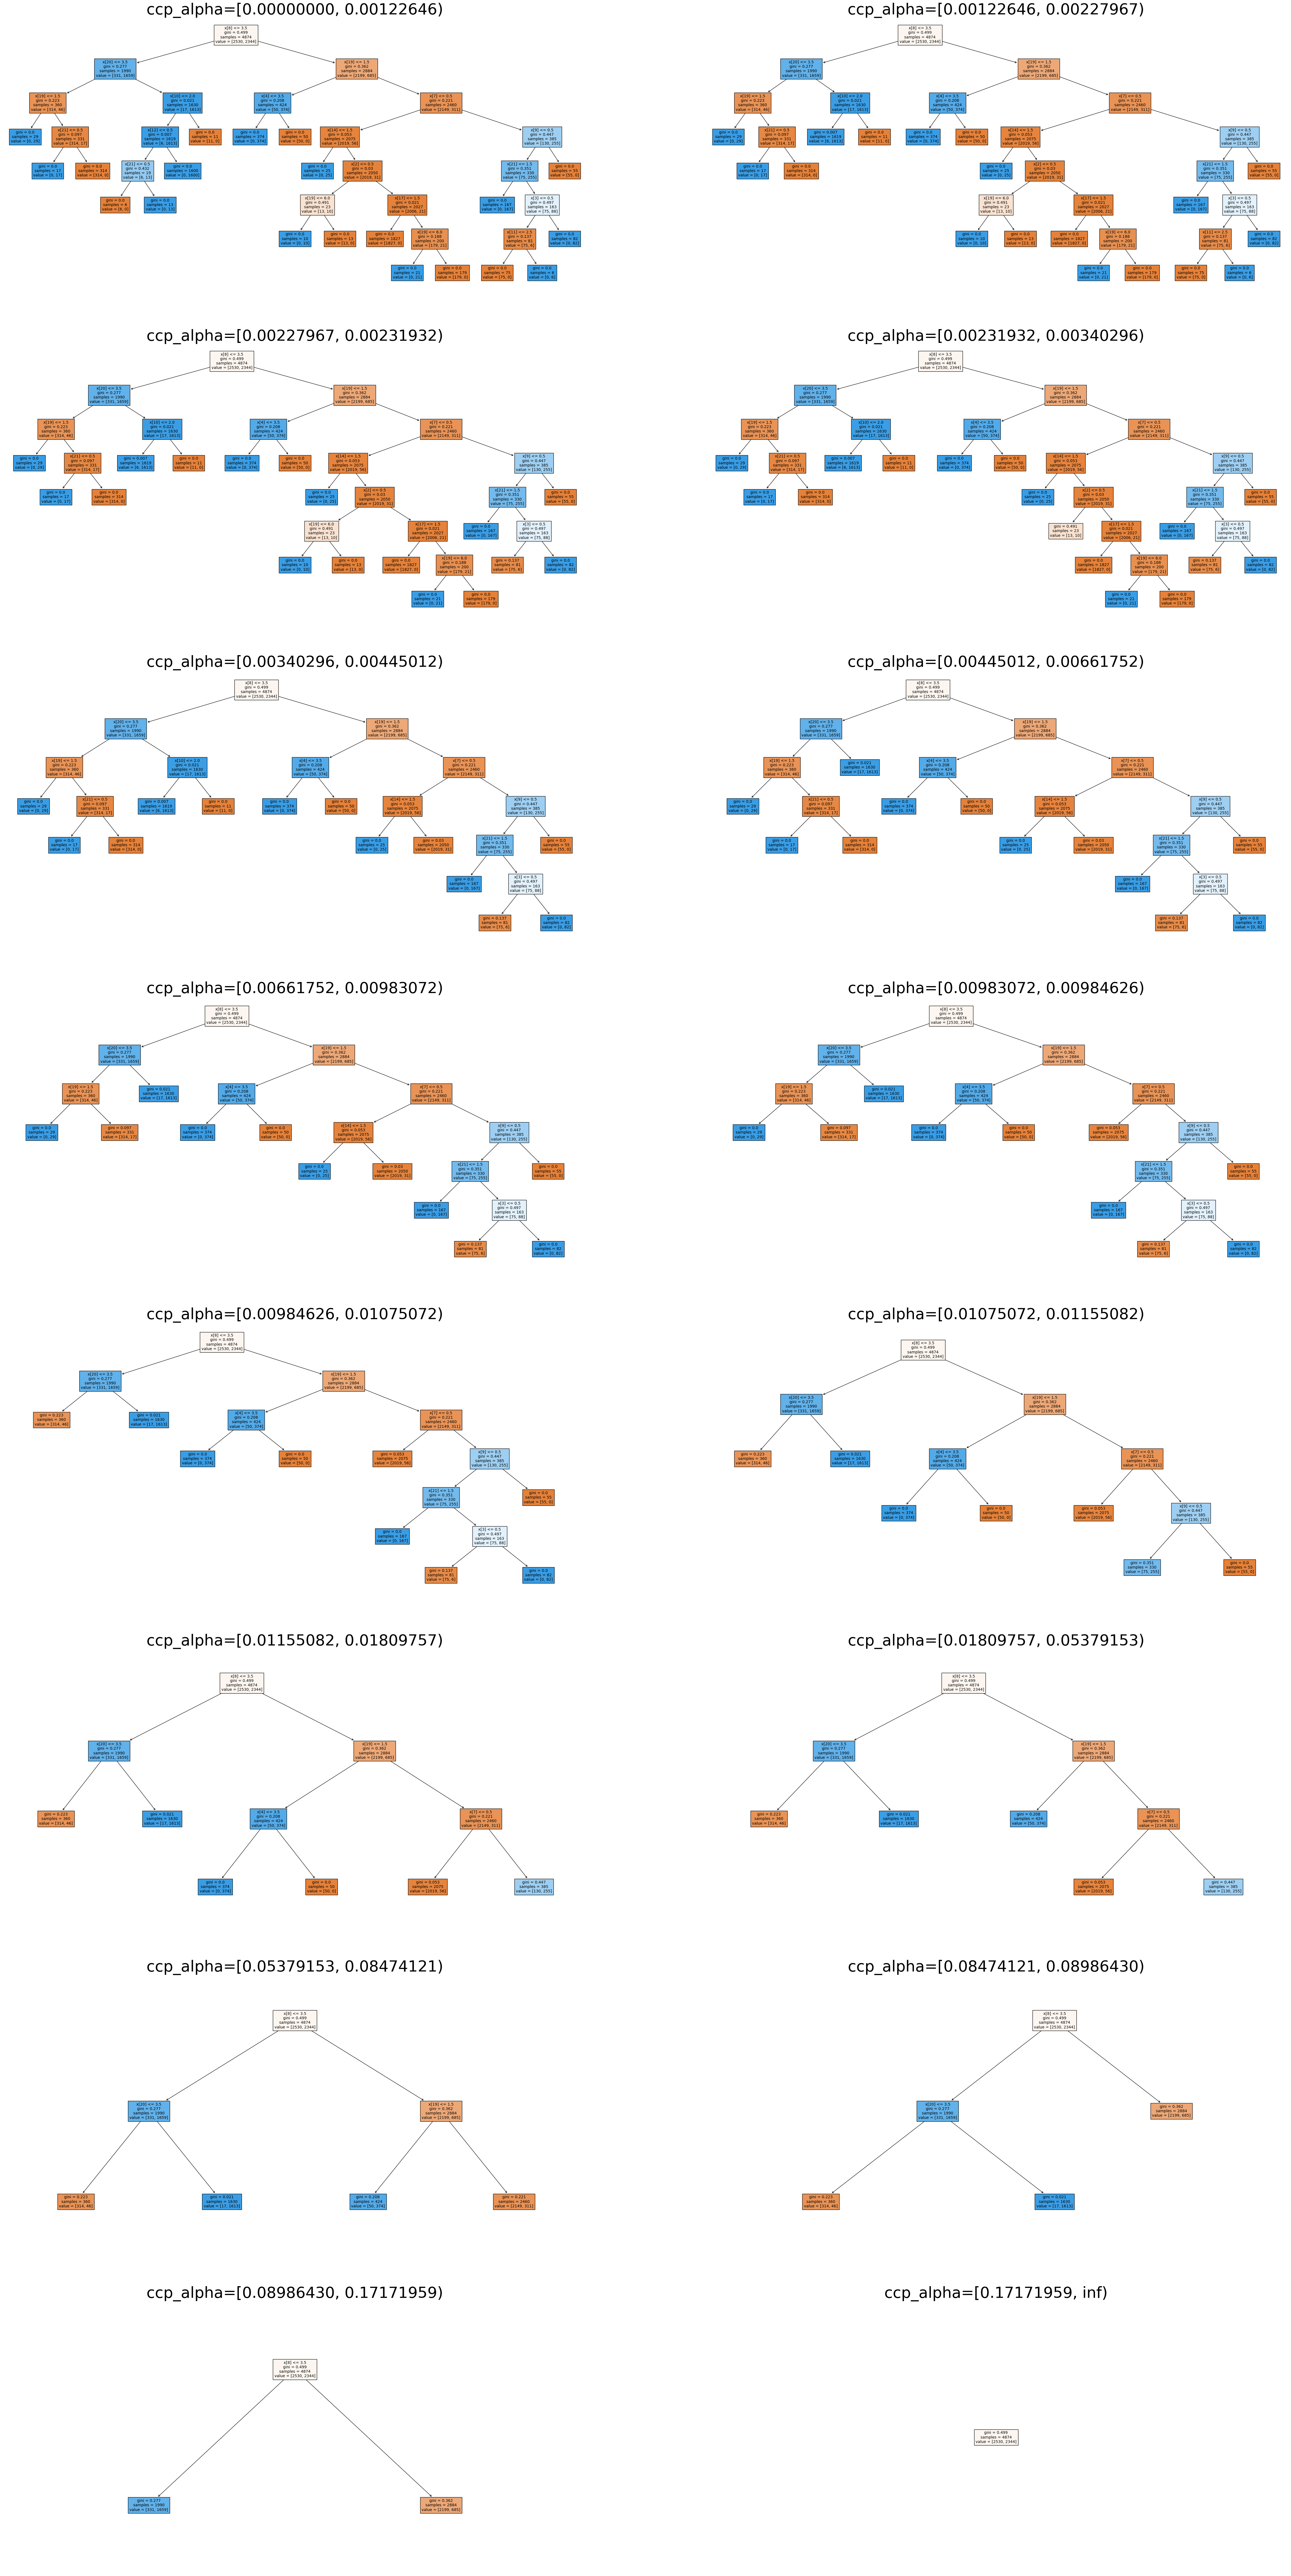

In [28]:
fig1, axes1 = plt.subplots(figsize=(60, 120), ncols=2, nrows=int(np.ceil(len(eff_alphas) / 2)))
for i, ax1 in enumerate(axes1.flatten()):
    tmp_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=eff_alphas[i])
    tmp_clf.fit(X1_train_enc, y1_train)
    plot_tree(tmp_clf, ax=ax1, fontsize=10, filled=True)
    ax1.set_title(f"ccp_alpha=[{eff_alphas[i]:.8f}, {np.inf if i + 1 >= len(eff_alphas) else eff_alphas[i + 1]:.8f})", fontsize=40);

In [29]:
eff_alphas, impurities = dtc.cost_complexity_pruning_path(X1_train_enc, y1_train).values()
eff_alphas  # to check if the values are the same as what we have calculated

array([0.        , 0.00122646, 0.00227967, 0.00231932, 0.00340296,
       0.00445012, 0.00661752, 0.00983072, 0.00984626, 0.01075072,
       0.01155082, 0.01809757, 0.05379153, 0.08474121, 0.0898643 ,
       0.17171959])

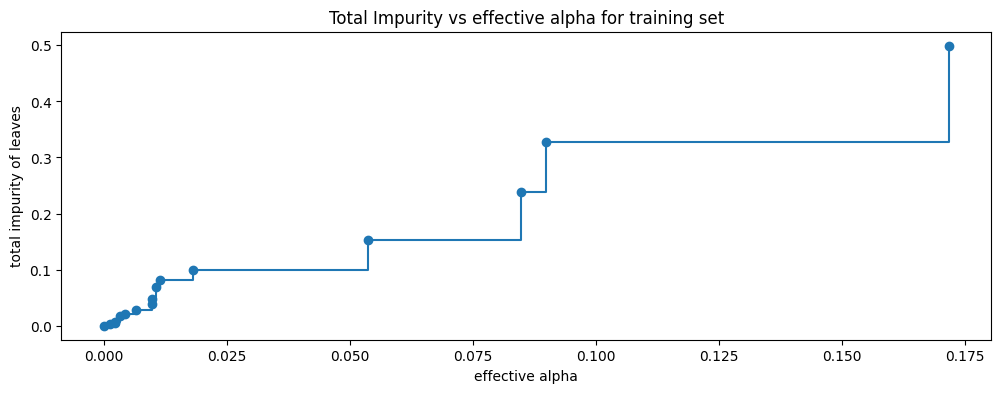

In [30]:
_, ax = plt.subplots(figsize=(12, 4))  # to adjust size
ax.plot(eff_alphas, impurities, marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set");

As mentioned earlier, (post-)pruning typically reduces the training accuracy in exchange for better generalization on the test set. Therefore, in practice, we use cross-validation to find the `ccp_alpha` value that yields the best results.

In [31]:
eff_alphas_breast, _ = dtc1.cost_complexity_pruning_path(X2_train, y2_train).values()

eff_alphas_breast = eff_alphas_breast[:-1]
train_scores = []
test_scores = []
for eff_alpha in eff_alphas_breast:
    tmp_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=eff_alpha)
    tmp_clf.fit(X2_train, y2_train)
    train_scores.append(tmp_clf.score(X2_train, y2_train))
    test_scores.append(tmp_clf.score(X2_test, y2_test))

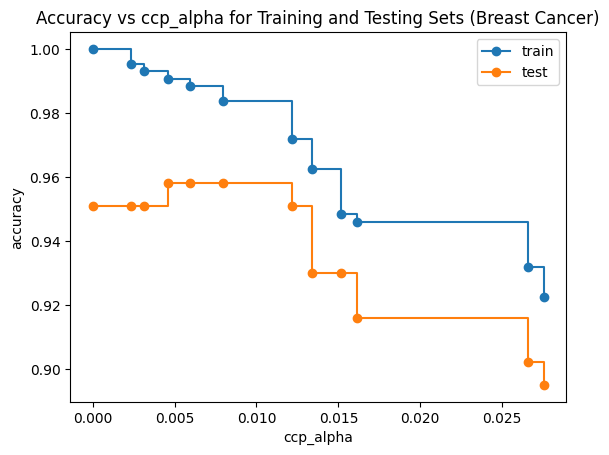

In [32]:
fig, ax = plt.subplots()
plt.plot(eff_alphas_breast, train_scores, marker="o", label="train", drawstyle="steps-post")
plt.plot(eff_alphas_breast, test_scores, marker="o", label="test", drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("accuracy")
plt.title("Accuracy vs ccp_alpha for Training and Testing Sets (Breast Cancer)")
plt.legend();

We may conclude that setting `ccp_alpha` at around 0.005 to 0.010 maximizes the testing accuracy.

## Key Takeaways

- Decision trees split data based on feature conditions to create a hierarchy of decisions. (`sklearn.tree.DecisionTreeClassifier/DecisionTreeRegressor`)
- Splitting criteria such as Shannon entropy or Gini impurity are used to choose the most informative features for each split.
- Ordinal encoding converts categorical features with an inherent order into integer values. (`sklearn.preprocessing.OrdinalEncoder`)
- Pre-pruning halts tree growth early by imposing limits, whereas post-pruning refines a fully grown tree by removing branches that contribute little to overall performance. (`sklearn.tree.DecisionTreeClassifier/DecisionTreeRegressor.cost_complexity_pruning_path`)